In [1]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import util as yu
from util import *
import util_NpiScatteringWilson as yun

yu.setpath('analysis')

ens='milc'

In [2]:
def symmetrize(dat):
    dat_bw=np.roll(np.flip(dat,axis=1),1,axis=1)
    return((dat[:,:,0]+dat[:,:,5]) - (dat_bw[:,:,10]+dat_bw[:,:,15]))/4

d_jk=4
Nsrc=200; Ncfg=1418
path=f'/capstor/store/cscs/userlab/lp139/lyan/code/projectData/03_NpiScatteringWilson/MILC_a09m130W/data_merge/NpiScatteringWilson_Nsrc={Nsrc}_{Ncfg}cfgs.h5'
data={}
with h5py.File(path) as f:    
    cfgs_all=[cfg.decode() for cfg in f['cfgs'][:]]
    # cfgs_map=[cfgs_all.index(cfg) for cfg in cfgs]
    
    if True:
        cfgs_map=[cfgs_all.index(cfg) for cfg in cfgs_all]
    
    for cont in f['data'].keys():
        if cont in ['N']:
            t=f[f'data/{cont}'][:,:,16]
            t=symmetrize(t)
            t=np.real(t)
            data[cont]=yu.jackknife(t[cfgs_map],d=d_jk)
            continue
        if cont in ['P']:
            t=f[f'data/{cont}'][:,:,0]
            t_bw=np.roll(np.flip(t,axis=1),1,axis=1)
            t=(t+t_bw)/2
            t=np.real(t)
            data[cont]=yu.jackknife(t[cfgs_map],d=d_jk)
            continue
        t=f[f'data/{cont}'][:,:,0]
        t=symmetrize(t)
        t=np.real(t)
        data[cont]=yu.jackknife(t[cfgs_map],d=d_jk)

Njk=len(data['N'])
print(data['N'].shape)

path='pkl/analysis_c2pt_pi_N/reg_ignore/mpi.pkl'
mpi_jk=yu.load_pkl(path)

path='pkl/analysis_c2pt_pi_N/reg_ignore/pars_jk_meffnst_selected.pkl'
[pars_jk_meff1st,pars_jk_meff2st,pars_jk_meff3st]=yu.load_pkl(path)

mN_jk=pars_jk_meff2st[:,0]

(354, 96)


In [3]:
coeffs_32=[[[1,'B232'],[-1,'B122']],[[1,'W1222'],[-1,'W1321'],[1,'W1322'],[-1,'W2321']],[[-1,'Z114'],[1,'Z132'],[-1,'Z214'],[-1,'Z222']]]
coeffs_12=[[[-3/2,'B114'],[1/2,'B122'],[3/2,'B132'],[-3/2,'B214'],[1,'B232']],
           [[-3/2,'W1141'],[3/2,'W1142'],[3/2,'W1221'],[-1/2,'W1222'],[1/2,'W1321'],[-1/2,'W1322'],[-1,'W2321']],
           [[1/2,'Z114'],[-3/2,'Z122'],[-1/2,'Z132'],[1/2,'Z214'],[-1,'Z222']]
]
method=['2','2','1']

Nstoc=12

c_12=np.real(data['M'][:,:,0]+np.sum([
    np.mean(cont[0]*data[f'{cont[1]}_{method}'][:,:,:] if cont[1][0] in [] else cont[0]*data[f'{cont[1]}_{method}'][:,:,:Nstoc],axis=-1)
    for conts,method in zip(coeffs_12,method) for cont in conts],axis=0))
c_32=np.real(data['M'][:,:,0]+np.sum([
    np.mean(cont[0]*data[f'{cont[1]}_{method}'][:,:,:] if cont[1][0] in [] else cont[0]*data[f'{cont[1]}_{method}'][:,:,:Nstoc],axis=-1)
    for conts,method in zip(coeffs_32,method) for cont in conts],axis=0))
c_Npi=np.real(data['N']*data['P'])
c_N=np.real(data['N'])
c_pi=np.real(data['P'])

isos=['32','12']
iso2c={'32':c_32,'12':c_12}

32
       1   0.9857   0.9562   0.9195    0.873   0.8206   0.7644   0.6472   0.6051   0.5543
  0.9857        1   0.9818   0.9491     0.91   0.8599   0.8034   0.6781   0.6363   0.5864
  0.9562   0.9818        1   0.9782   0.9441   0.8872   0.8246   0.6975   0.6512   0.6044
  0.9195   0.9491   0.9782        1   0.9756   0.9276   0.8637   0.7291   0.6662   0.5866
   0.873     0.91   0.9441   0.9756        1   0.9623   0.9027   0.7797   0.7109   0.6265
  0.8206   0.8599   0.8872   0.9276   0.9623        1    0.957   0.8274   0.7468   0.6243
  0.7644   0.8034   0.8246   0.8637   0.9027    0.957        1   0.9151   0.8243   0.6884
  0.6472   0.6781   0.6975   0.7291   0.7797   0.8274   0.9151        1   0.9277   0.7904
  0.6051   0.6363   0.6512   0.6662   0.7109   0.7468   0.8243   0.9277        1   0.9036
  0.5543   0.5864   0.6044   0.5866   0.6265   0.6243   0.6884   0.7904   0.9036        1


12
       1   0.9832    0.952   0.9119   0.8637   0.8009   0.7366   0.4981   0.5402   0.3792
  0.9832        1   0.9783   0.9442   0.9003   0.8364   0.7672   0.5225   0.5772   0.4284
   0.952   0.9783        1   0.9763   0.9353   0.8631   0.7866    0.543    0.592   0.4444
  0.9119   0.9442   0.9763        1   0.9685   0.9038   0.8238    0.596   0.6186   0.4741
  0.8637   0.9003   0.9353   0.9685        1   0.9532   0.8744    0.654   0.6569   0.4993
  0.8009   0.8364   0.8631   0.9038   0.9532        1   0.9235   0.7226   0.6897   0.5125
  0.7366   0.7672   0.7866   0.8238   0.8744   0.9235        1   0.8052   0.7507   0.5683
  0.4981   0.5225    0.543    0.596    0.654   0.7226   0.8052        1   0.8488   0.7227
  0.5402   0.5772    0.592   0.6186   0.6569   0.6897   0.7507   0.8488        1   0.8431
  0.3792   0.4284   0.4444   0.4741   0.4993   0.5125   0.5683   0.7227   0.8431        1


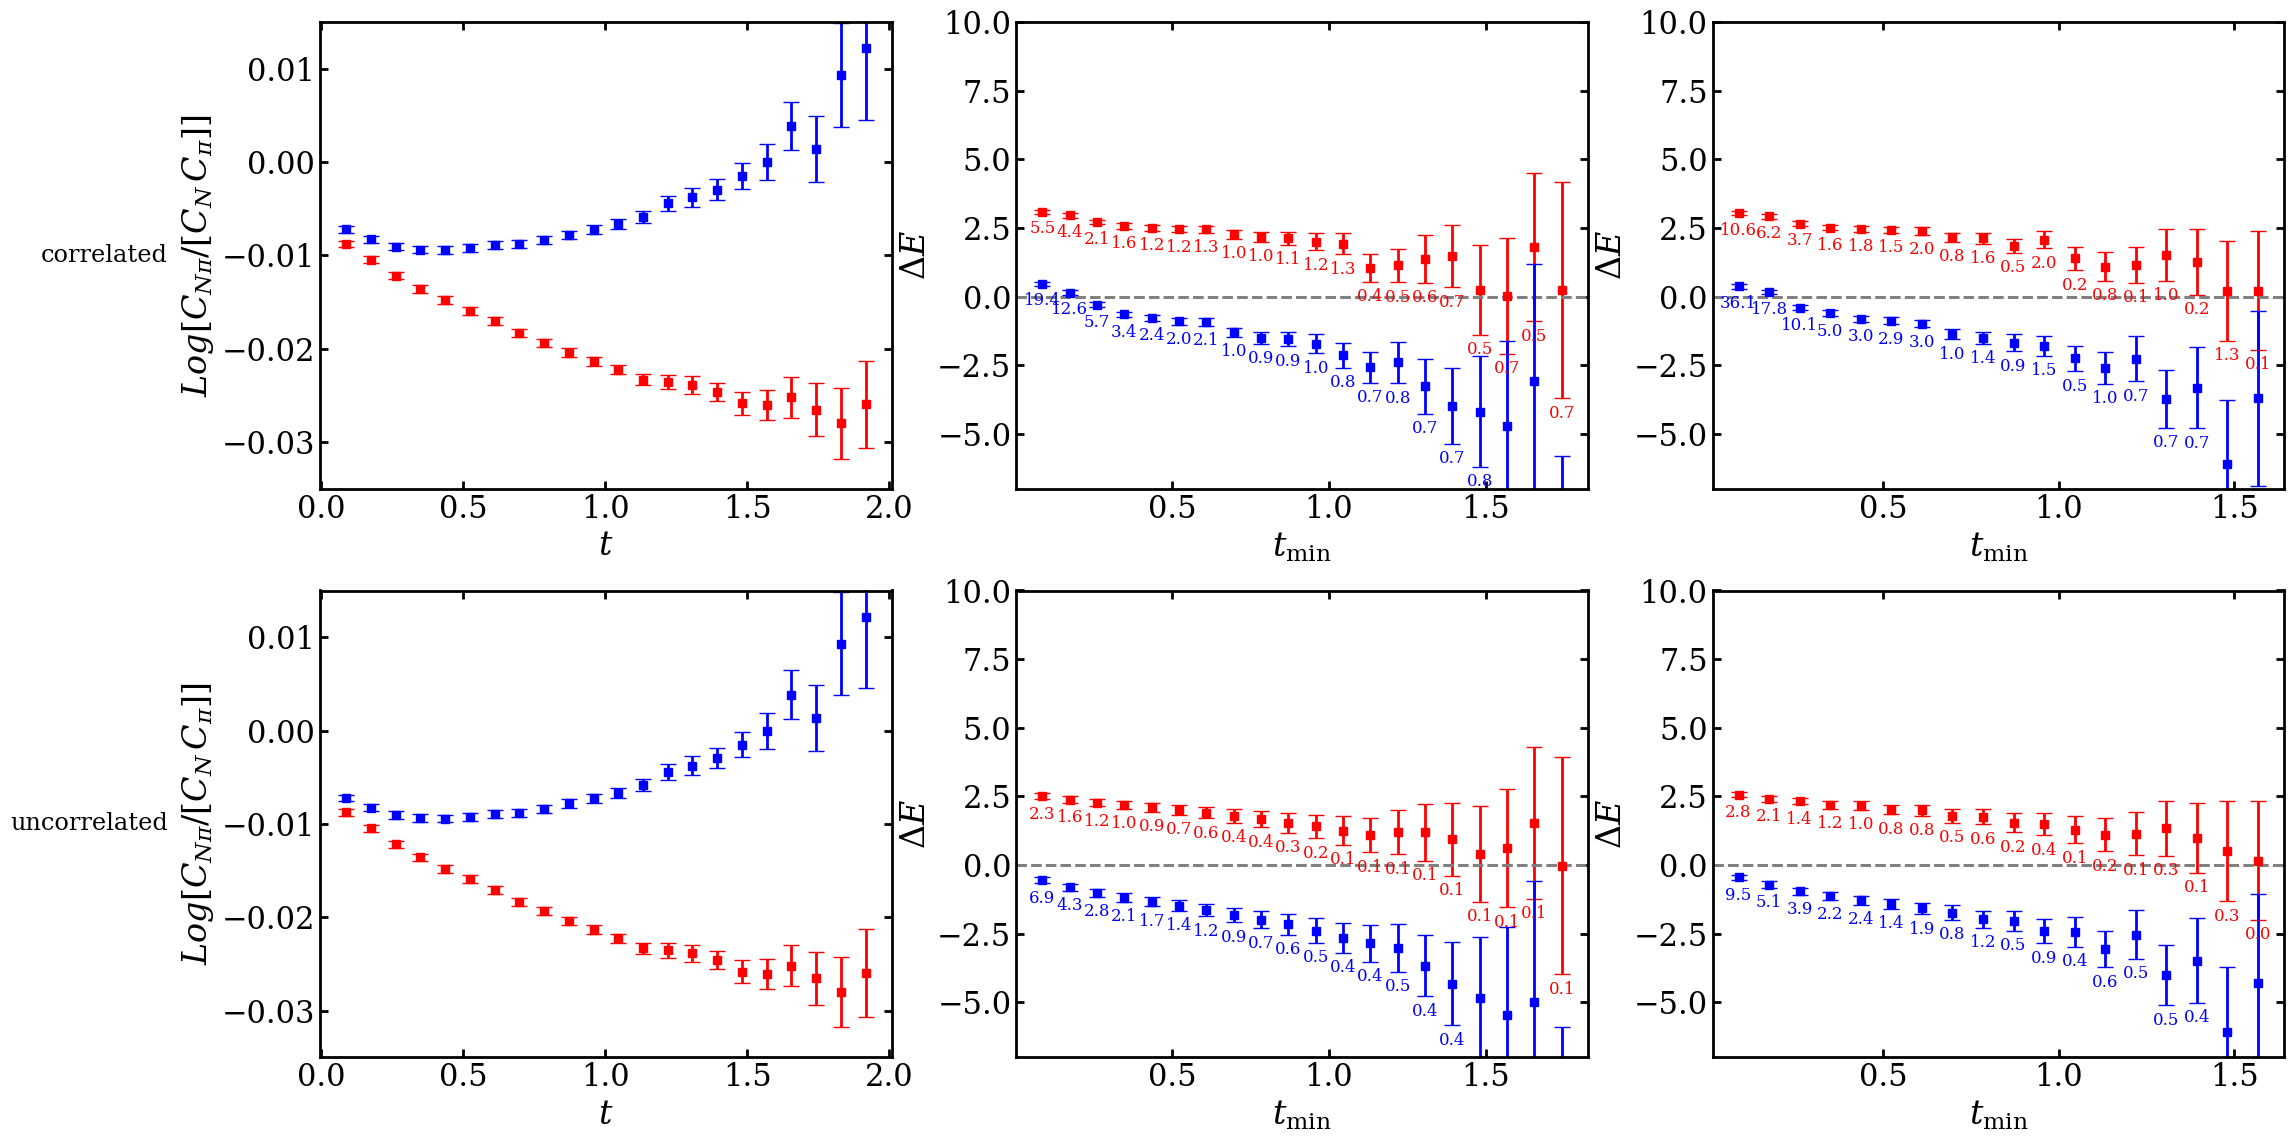

In [28]:
dt=1
ylim_dE=[-7,10]
fig,axs=yu.getFigAxs(2,3)
yu.addRowHeader(axs,['correlated','uncorrelated'])
for ic,corrQ in enumerate([True,False]):
    colors=['r','b']

    for iiso,iso in enumerate(isos):
        ax=axs[ic,0]
        ax.set_ylim([-0.035,0.015])
        ax.set_xlabel(r'$t$')
        ax.set_ylabel(r'$Log[C_{N\pi}/[C_{N}\,C_{\pi}]]$')
        xunit=yun.ens2a[ens]; yunit=1
        # ax.set_ylim([0.95,1.02])
        # yu.addRefLine(ax,0)
        
        fitmax=round(2/yun.ens2a[ens])
        
        c0=iso2c[iso]/c_Npi
        func=lambda c2pt:np.log(c2pt/np.roll(c2pt,-dt,axis=0))/dt
        dm=yu.jackmap(func,c0)
        
        c=np.log(iso2c[iso]/c_Npi)

        ts=np.arange(1,fitmax)
        
        mean,err=yu.jackme(c)
        plt_x=ts*xunit; plt_y=mean[ts]*yunit; plt_yerr=err[ts]*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])

        ax=axs[ic,1]
        ax.set_xlabel(r'$t_{\rm min}$')
        ax.set_ylabel(r'$\Delta E$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        ax.set_ylim(ylim_dE)
        yu.addRefLine(ax,0)
        
        y_jk=np.log(iso2c[iso]/c_Npi)
        ts=np.arange(len(y_jk[0]))
        
        if corrQ:
            print(iso)
            m,e,c=yu.jackmec(y_jk[:,5:15])
            print(yu.formatMatrix(yu.cov2correlation(c)))
        
        tmins=np.arange(1,fitmax-2); tmaxs=[fitmax]
        tmax=fitmax
        fits=[]
        for tmin in tmins:
            inds=[i for i,t in enumerate(ts) if tmin<=t<tmax]
            pars_jk,chi2_jk,Ndof=yu.doFit_linear(ts[inds],y_jk[:,inds],corrQ=corrQ)
            fits.append([(tmin,tmax),pars_jk,chi2_jk,Ndof])
            
        for fit in fits:
            (tmin,tmax),pars_jk,chi2_jk,Ndof=fit
            mean,err=yu.jackme(-pars_jk[:,1])
            plt_x=(tmin+0.2*tmaxs.index(tmax))*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
            ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])
            
            chi2R=np.mean(chi2_jk)/Ndof
            ylim=ax.get_ylim(); chi2_shift=(ylim[1]-ylim[0])/24; chi2Size=12
            ax.annotate("%0.1f" %chi2R,(plt_x,plt_y-plt_yerr-chi2_shift),color=colors[iiso],size=chi2Size,ha='center')
            
        ax=axs[ic,2]
        ax.set_xlabel(r'$t_{\rm min}$')
        ax.set_ylabel(r'$\Delta E$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        ax.set_ylim(ylim_dE)
        yu.addRefLine(ax,0)
        
        tmins=np.arange(1,fitmax-4); tmaxs=[fitmax]
        tmax=fitmax
        fits=[]
        for tmin in tmins:
            inds=[i for i,t in enumerate(ts) if tmin<=t<tmax and (t-tmin)%2==0]
            pars_jk,chi2_jk,Ndof=yu.doFit_linear(ts[inds],y_jk[:,inds],corrQ=corrQ)
            fits.append([(tmin,tmax),pars_jk,chi2_jk,Ndof])
            
        for fit in fits:
            (tmin,tmax),pars_jk,chi2_jk,Ndof=fit
            mean,err=yu.jackme(-pars_jk[:,1])
            plt_x=(tmin+0.2*tmaxs.index(tmax))*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
            ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])
            
            chi2R=np.mean(chi2_jk)/Ndof
            ylim=ax.get_ylim(); chi2_shift=(ylim[1]-ylim[0])/24; chi2Size=12
            ax.annotate("%0.1f" %chi2R,(plt_x,plt_y-plt_yerr-chi2_shift),color=colors[iiso],size=chi2Size,ha='center')

yu.finalizePlot()

32
       1   0.3526   0.0859   0.1898  0.09232 -0.009145   -0.101  0.08126   0.1497  0.04418
  0.3526        1   0.2501   0.1192 -0.09788  -0.1135 -0.02247 -0.01475   0.1082   0.0324
  0.0859   0.2501        1   0.2201   0.1847 -0.00216 -0.05151  -0.1627  -0.3059  -0.1369
  0.1898   0.1192   0.2201        1   0.1968  0.06716   0.1478  0.01476  0.08389 -0.02385
 0.09232 -0.09788   0.1847   0.1968        1   0.1923 -0.05727 -0.03821  -0.1822  -0.1298
-0.009145  -0.1135 -0.00216  0.06716   0.1923        1   0.3948  0.01541  0.06463  0.02805
  -0.101 -0.02247 -0.05151   0.1478 -0.05727   0.3948        1   0.2055   0.1708   0.2094
 0.08126 -0.01475  -0.1627  0.01476 -0.03821  0.01541   0.2055        1   0.4268   0.2211
  0.1497   0.1082  -0.3059  0.08389  -0.1822  0.06463   0.1708   0.4268        1   0.3153
 0.04418   0.0324  -0.1369 -0.02385  -0.1298  0.02805   0.2094   0.2211   0.3153        1
12
       1   0.2469   0.1264  0.07606  -0.0162 -0.05554 -0.05225   0.1984   0.1978   0.0885
  

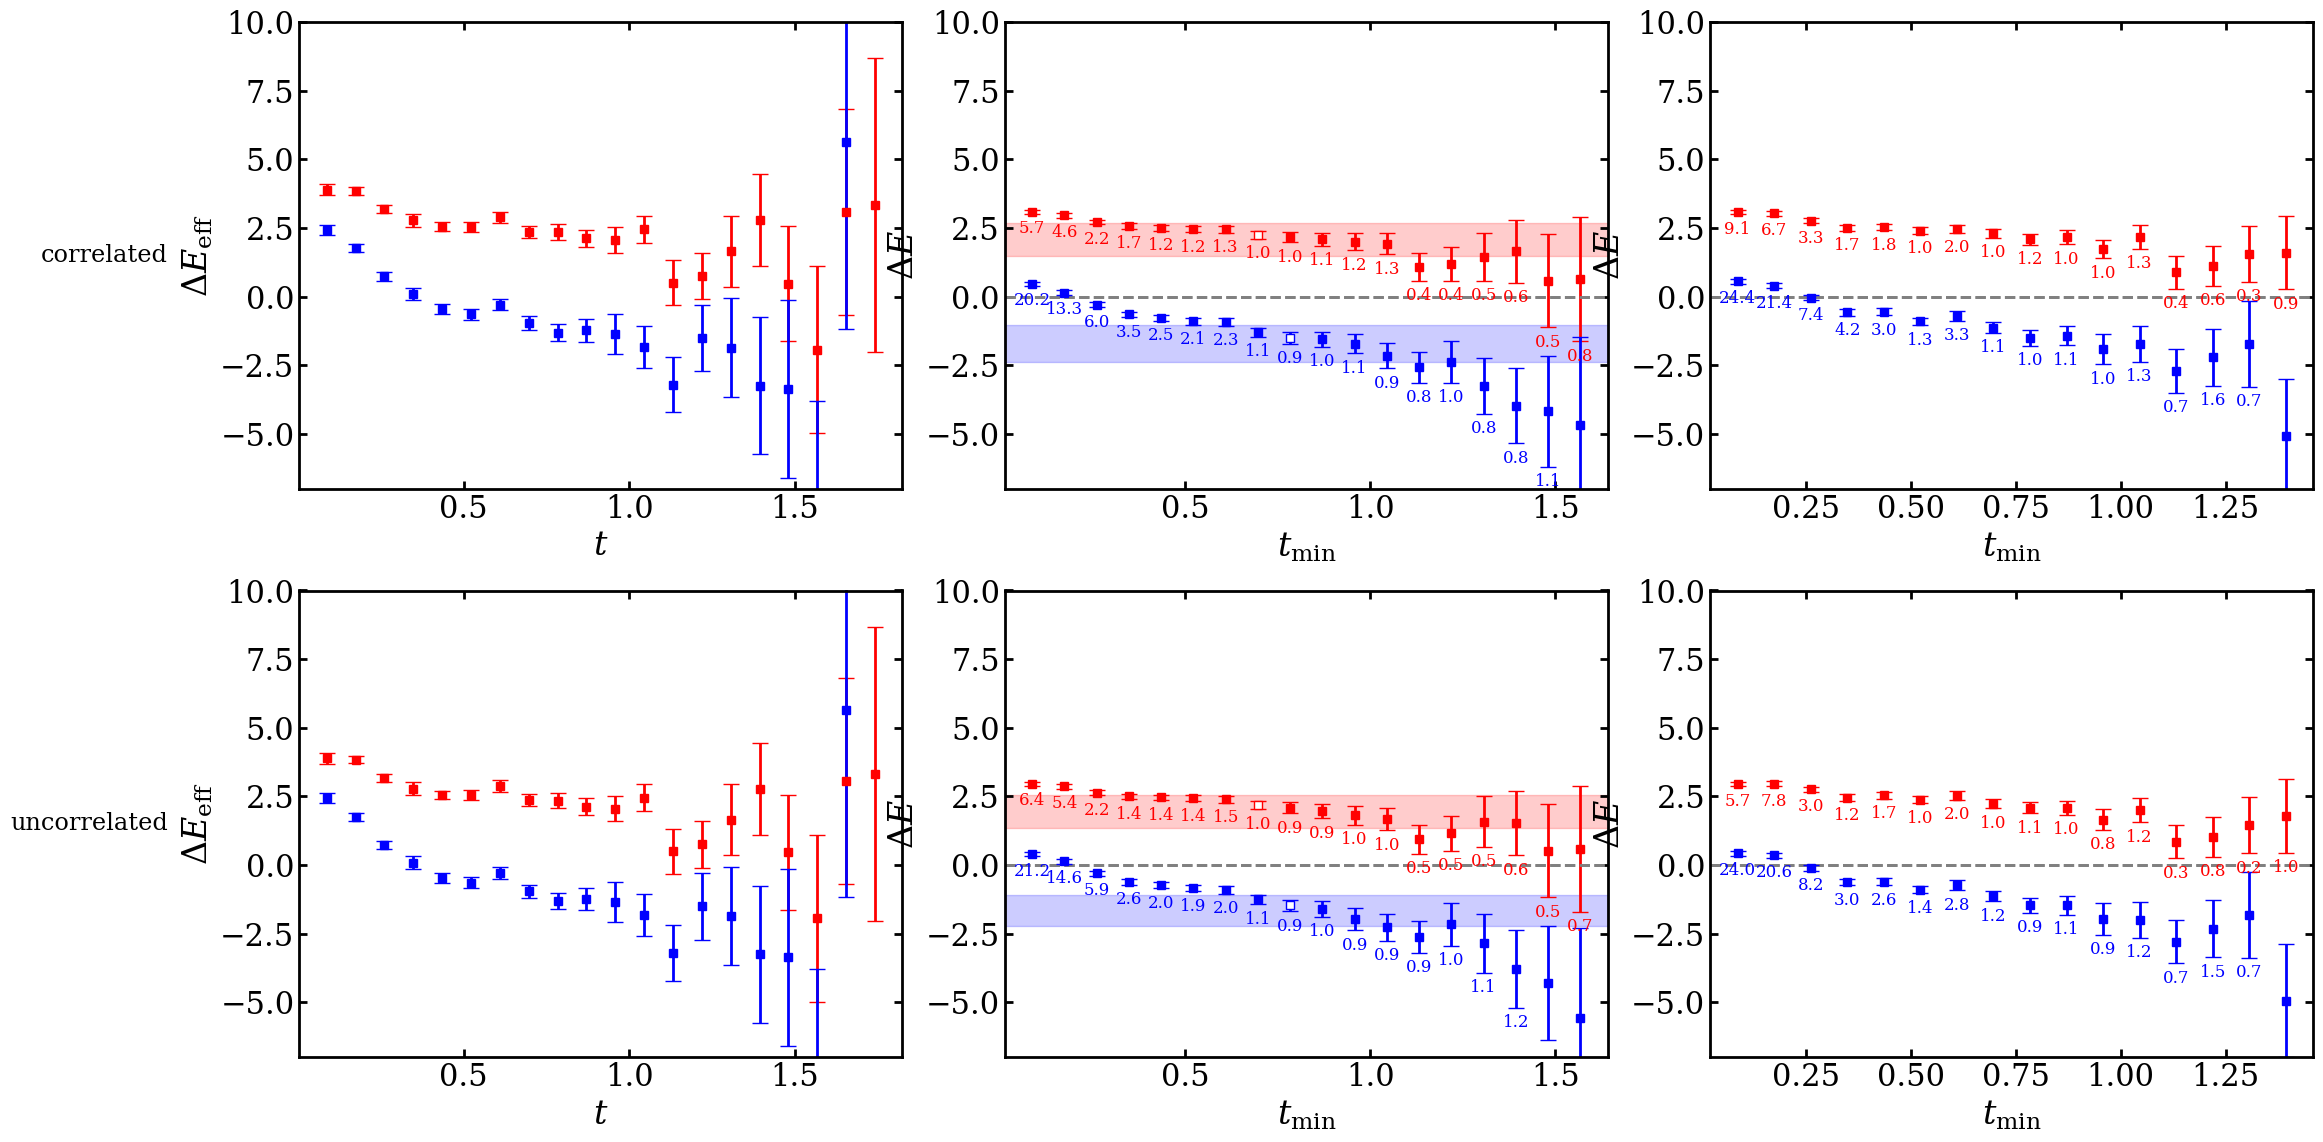

In [41]:
dt=1
ylim_dE=[-7,10]
fig,axs=yu.getFigAxs(2,3)
yu.addRowHeader(axs,['correlated','uncorrelated'])
for ic,corrQ in enumerate([True,False]):
    colors=['r','b']

    for iiso,iso in enumerate(isos):
        ax=axs[ic,0]
        ax.set_ylim(ylim_dE)
        ax.set_xlabel(r'$t$')
        ax.set_ylabel(r'$\Delta E_{\rm eff}$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        # ax.set_ylim([0.95,1.02])
        # yu.addRefLine(ax,0)
        
        fitmax=round(1.8/yun.ens2a[ens])
        
        c0=iso2c[iso]/c_Npi
        func=lambda c2pt:np.log(c2pt/np.roll(c2pt,-dt,axis=0))/dt
        dm=yu.jackmap(func,c0)
        
        c=np.log(iso2c[iso]/c_Npi)

        ts=np.arange(1,fitmax)
        
        mean,err=yu.jackme(dm)
        plt_x=ts*xunit; plt_y=mean[ts]*yunit; plt_yerr=err[ts]*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])

        ax=axs[ic,1]
        ax.set_xlabel(r'$t_{\rm min}$')
        ax.set_ylabel(r'$\Delta E$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        ax.set_ylim(ylim_dE)
        yu.addRefLine(ax,0)
        
        y_jk=dm
        ts=np.arange(len(y_jk[0]))
        
        if corrQ:
            print(iso)
            m,e,c=yu.jackmec(y_jk[:,5:15])
            print(yu.formatMatrix(yu.cov2correlation(c)))
        
        tmins=np.arange(1,fitmax-2); tmaxs=[fitmax]
        tmax=fitmax
        fits=[]
        for tmin in tmins:
            inds=[i for i,t in enumerate(ts) if tmin<=t<tmax]
            pars_jk,chi2_jk,Ndof=yu.doFit_const(y_jk[:,inds],corrQ=corrQ)
            fits.append([(tmin,tmax),pars_jk,chi2_jk,Ndof])
            
        fits_MA=fits
        # fits_MA=[fit for fit in fits if fit[0][0] >= round(1/yun.ens2a[ens])]
        (pars_mean_MA,pars_err_MA,probs, pars_err_MA_stats, pars_err_MA_systs)=yu.modelAvg(fits_MA,jackInputQ=True,fullOutputQ=True)
        fitlabel_mpf=fits_MA[np.argmax(probs)][0]
        plt_y=pars_mean_MA[0] * yunit; plt_yerr= pars_err_MA[0] * yunit
        ymin=plt_y-plt_yerr; ymax= plt_y + plt_yerr
        ax.axhspan(ymin, ymax, alpha=0.2, color=colors[iiso], label = yu.un2str(plt_y,plt_yerr))
            
        for fit in fits:
            (tmin,tmax),pars_jk,chi2_jk,Ndof=fit
            mean,err=yu.jackme(pars_jk[:,0])
            plt_x=(tmin+0.2*tmaxs.index(tmax))*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
            ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso], mfc='white' if (tmin,tmax)==fitlabel_mpf else None)
            
            chi2R=np.mean(chi2_jk)/Ndof
            ylim=ax.get_ylim(); chi2_shift=(ylim[1]-ylim[0])/24; chi2Size=12
            ax.annotate("%0.1f" %chi2R,(plt_x,plt_y-plt_yerr-chi2_shift),color=colors[iiso],size=chi2Size,ha='center')
            
        ax=axs[ic,2]
        ax.set_xlabel(r'$t_{\rm min}$')
        ax.set_ylabel(r'$\Delta E$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        ax.set_ylim(ylim_dE)
        yu.addRefLine(ax,0)
        
        tmins=np.arange(1,fitmax-4); tmaxs=[fitmax]
        tmax=fitmax
        fits=[]
        for tmin in tmins:
            inds=[i for i,t in enumerate(ts) if tmin<=t<tmax and (t-tmin)%2==0]
            pars_jk,chi2_jk,Ndof=yu.doFit_const(y_jk[:,inds],corrQ=corrQ)
            fits.append([(tmin,tmax),pars_jk,chi2_jk,Ndof])
            
        for fit in fits:
            (tmin,tmax),pars_jk,chi2_jk,Ndof=fit
            mean,err=yu.jackme(pars_jk[:,0])
            plt_x=(tmin+0.2*tmaxs.index(tmax))*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
            ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])
            
            chi2R=np.mean(chi2_jk)/Ndof
            ylim=ax.get_ylim(); chi2_shift=(ylim[1]-ylim[0])/24; chi2Size=12
            ax.annotate("%0.1f" %chi2R,(plt_x,plt_y-plt_yerr-chi2_shift),color=colors[iiso],size=chi2Size,ha='center')

yu.finalizePlot()

32
       1   0.6513   0.2542  0.09555 -0.05883 -0.08816 -0.02083   0.1282   0.1224 -0.02031
  0.6513        1   0.6479   0.1679  -0.0074 -0.06689   -0.107  -0.1515  -0.1277  0.02744
  0.2542   0.6479        1    0.621   0.1806  0.06742 -0.02033  -0.1388  -0.1448 -0.03105
 0.09555   0.1679    0.621        1   0.6391   0.1139  0.01177 -0.07196  -0.1198 0.006649
-0.05883  -0.0074   0.1806   0.6391        1   0.5434   0.1346 -0.05629 -0.08045  0.02378
-0.08816 -0.06689  0.06742   0.1139   0.5434        1     0.66   0.1786    0.194  -0.1434
-0.02083   -0.107 -0.02033  0.01177   0.1346     0.66        1   0.6344   0.4109 -0.06054
  0.1282  -0.1515  -0.1388 -0.07196 -0.05629   0.1786   0.6344        1   0.7619 -0.00129
  0.1224  -0.1277  -0.1448  -0.1198 -0.08045    0.194   0.4109   0.7619        1   0.2963
-0.02031  0.02744 -0.03105 0.006649  0.02378  -0.1434 -0.06054 -0.00129   0.2963        1
12
       1   0.6594   0.1893 -0.02057  -0.1242  -0.0613  0.07222    0.177   0.1187 -0.04997
  0.

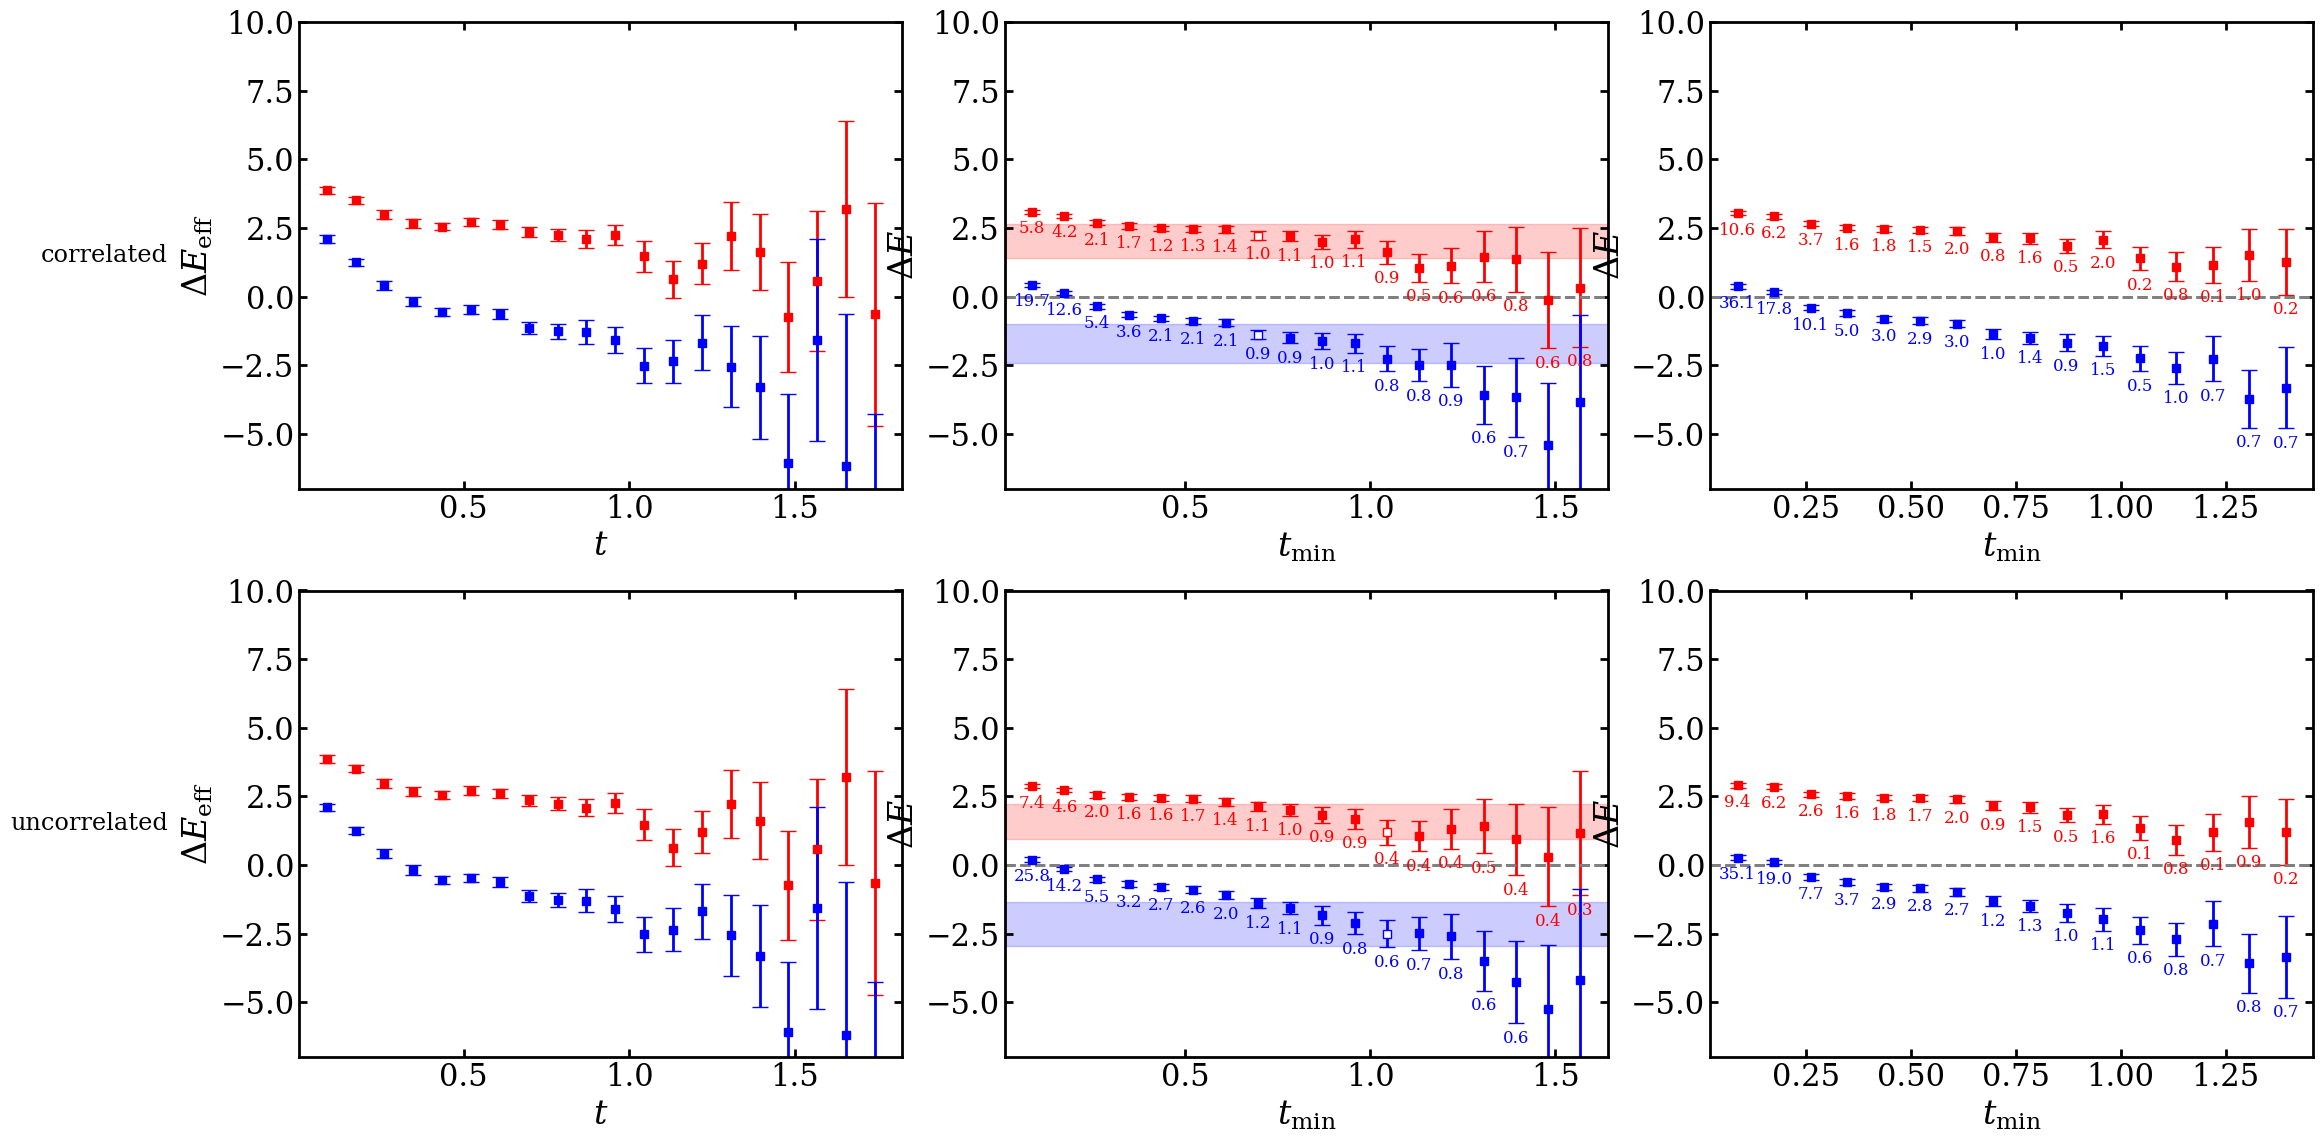

In [40]:
dt=2
ylim_dE=[-7,10]
fig,axs=yu.getFigAxs(2,3)
yu.addRowHeader(axs,['correlated','uncorrelated'])
for ic,corrQ in enumerate([True,False]):
    colors=['r','b']

    for iiso,iso in enumerate(isos):
        ax=axs[ic,0]
        ax.set_ylim(ylim_dE)
        ax.set_xlabel(r'$t$')
        ax.set_ylabel(r'$\Delta E_{\rm eff}$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        # ax.set_ylim([0.95,1.02])
        # yu.addRefLine(ax,0)
        
        fitmax=round(1.8/yun.ens2a[ens])
        
        c0=iso2c[iso]/c_Npi
        func=lambda c2pt:np.log(c2pt/np.roll(c2pt,-dt,axis=0))/dt
        dm=yu.jackmap(func,c0)
        
        c=np.log(iso2c[iso]/c_Npi)

        ts=np.arange(1,fitmax)
        
        mean,err=yu.jackme(dm)
        plt_x=ts*xunit; plt_y=mean[ts]*yunit; plt_yerr=err[ts]*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])

        ax=axs[ic,1]
        ax.set_xlabel(r'$t_{\rm min}$')
        ax.set_ylabel(r'$\Delta E$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        ax.set_ylim(ylim_dE)
        yu.addRefLine(ax,0)
        
        y_jk=dm
        ts=np.arange(len(y_jk[0]))

        if corrQ:
            print(iso)
            m,e,c=yu.jackmec(y_jk[:,5:15])
            print(yu.formatMatrix(yu.cov2correlation(c)))
        
        tmins=np.arange(1,fitmax-2); tmaxs=[fitmax]
        tmax=fitmax
        fits=[]
        for tmin in tmins:
            inds=[i for i,t in enumerate(ts) if tmin<=t<tmax]
            pars_jk,chi2_jk,Ndof=yu.doFit_const(y_jk[:,inds],corrQ=corrQ)
            fits.append([(tmin,tmax),pars_jk,chi2_jk,Ndof])
            
        # if corrQ:
        fits_MA=fits
        # fits_MA=[fit for fit in fits if fit[0][0] >= round(1/yun.ens2a[ens])]
        (pars_mean_MA,pars_err_MA,probs, pars_err_MA_stats, pars_err_MA_systs)=yu.modelAvg(fits_MA,jackInputQ=True,fullOutputQ=True)
        fitlabel_mpf=fits_MA[np.argmax(probs)][0]
        plt_y=pars_mean_MA[0] * yunit; plt_yerr= pars_err_MA[0] * yunit
        ymin=plt_y-plt_yerr; ymax= plt_y + plt_yerr
        ax.axhspan(ymin, ymax, alpha=0.2, color=colors[iiso], label = yu.un2str(plt_y,plt_yerr))
            
        for i,fit in enumerate(fits):
            (tmin,tmax),pars_jk,chi2_jk,Ndof=fit
            mean,err=yu.jackme(pars_jk[:,0])
            plt_x=(tmin+0.2*tmaxs.index(tmax))*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
            ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso], mfc='white' if (tmin,tmax)==fitlabel_mpf else None)
            
            chi2R=np.mean(chi2_jk)/Ndof
            ylim=ax.get_ylim(); chi2_shift=(ylim[1]-ylim[0])/24; chi2Size=12
            ax.annotate("%0.1f" %chi2R,(plt_x,plt_y-plt_yerr-chi2_shift),color=colors[iiso],size=chi2Size,ha='center')
            
            
        ax=axs[ic,2]
        ax.set_xlabel(r'$t_{\rm min}$')
        ax.set_ylabel(r'$\Delta E$')
        xunit=yun.ens2a[ens]; yunit=yun.ens2aInv[ens]
        ax.set_ylim(ylim_dE)
        yu.addRefLine(ax,0)
        
        tmins=np.arange(1,fitmax-4); tmaxs=[fitmax]
        tmax=fitmax
        fits=[]
        for tmin in tmins:
            inds=[i for i,t in enumerate(ts) if tmin<=t<tmax and (t-tmin)%2==0]
            pars_jk,chi2_jk,Ndof=yu.doFit_const(y_jk[:,inds],corrQ=corrQ)
            fits.append([(tmin,tmax),pars_jk,chi2_jk,Ndof])
            
        for fit in fits:
            (tmin,tmax),pars_jk,chi2_jk,Ndof=fit
            mean,err=yu.jackme(pars_jk[:,0])
            plt_x=(tmin+0.2*tmaxs.index(tmax))*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
            ax.errorbar(plt_x,plt_y,plt_yerr,color=colors[iiso])
            
            chi2R=np.mean(chi2_jk)/Ndof
            ylim=ax.get_ylim(); chi2_shift=(ylim[1]-ylim[0])/24; chi2Size=12
            ax.annotate("%0.1f" %chi2R,(plt_x,plt_y-plt_yerr-chi2_shift),color=colors[iiso],size=chi2Size,ha='center')

yu.finalizePlot()